In [2]:
import numpy as np
import pandas as pd
import mglearn
%matplotlib inline
import matplotlib.pyplot as plt

X.shape: (26, 2)


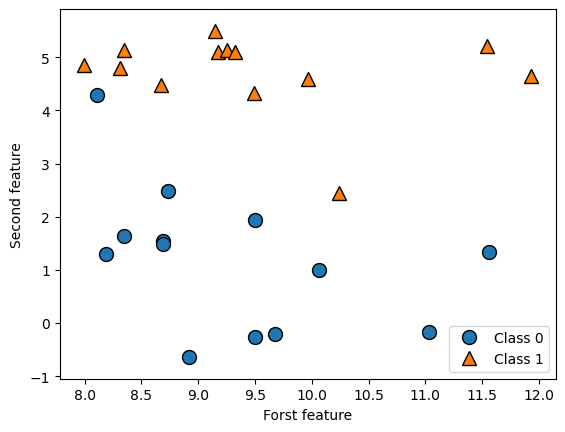

In [2]:
# generate dataset
X, y = mglearn.datasets.make_forge()

# plot dataset
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.legend(['Class 0', 'Class 1'], loc=4)
plt.xlabel('Forst feature')
plt.ylabel('Second feature')
print('X.shape: {}'.format(X.shape))



Text(0, 0.5, 'Target')

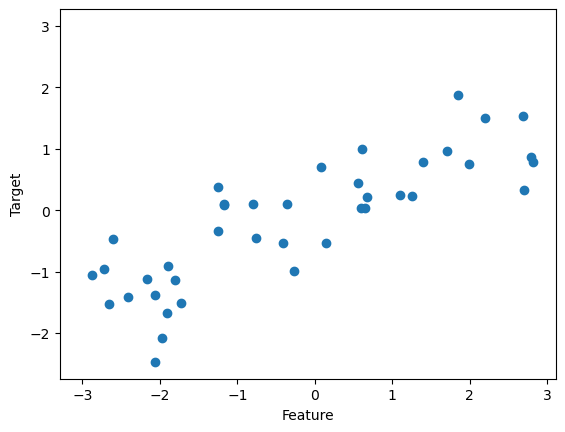

In [3]:
X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X, y, 'o')
plt.plot(-3, 3)
plt.xlabel('Feature')
plt.ylabel('Target')

In [4]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print('Cancer.keys(): \n{}'.format(cancer.keys()))

Cancer.keys(): 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
print('Shape of cancer data: {}'.format(cancer.data.shape))

Shape of cancer data: (569, 30)


In [6]:
print('Sample counts per class:\n{}'.format(
{n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}))

Sample counts per class:
{'malignant': 212, 'benign': 357}


In [7]:
print('Feature names:\n{}'.format(cancer.feature_names))

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


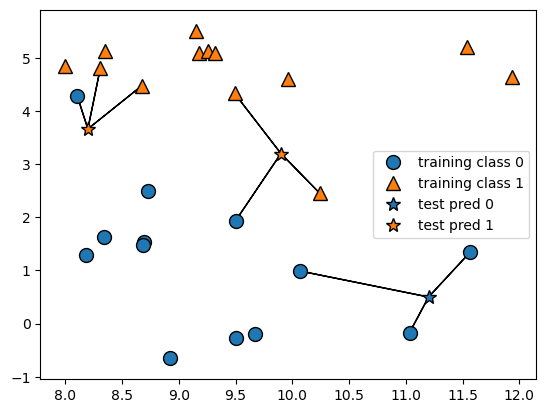

In [8]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X, y = mglearn.datasets.make_forge()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
print('Test set predictions: {}'.format(clf.predict(X_test)))
print('Test set accuracy: {:.2f}'.format(clf.score(X_test, y_test)))

Test set predictions: [1 0 1 0 1 0 0]
Test set accuracy: 0.86


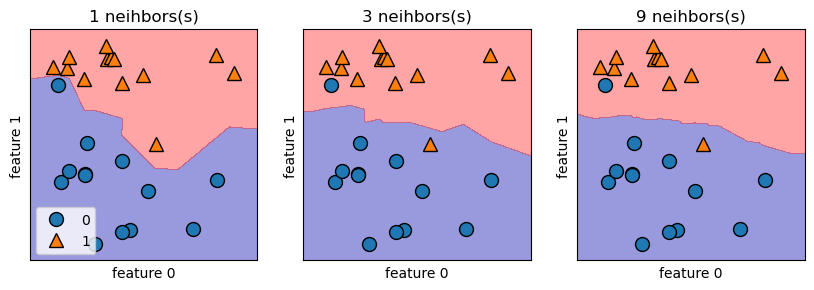

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10,3))

for n_neighbors, ax in zip([1, 3, 9], axes):
    # the fit method returns the object self, so we can instantiate
    # and fit in one line
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=0.4)
    mglearn.discrete_scatter(X[:,0], X[:,1], y, ax=ax)
    ax.set_title('{} neihbors(s)'.format(n_neighbors))
    ax.set_xlabel('feature 0')
    ax.set_ylabel('feature 1')
axes[0].legend(loc=3);

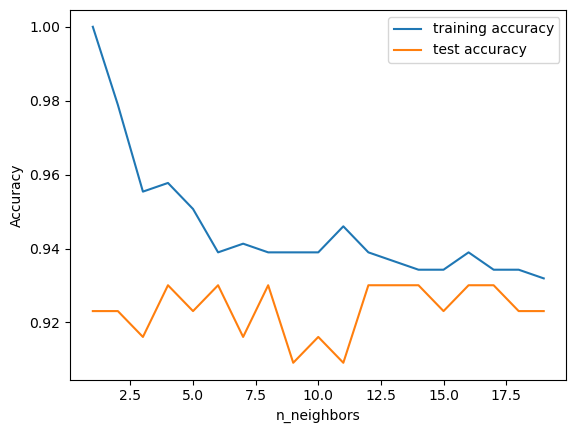

In [11]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=46)

training_accuracy = []
test_accuracy = []

# try n_neighbors from 1 to 10
neighbors_settings = range(1, 20)

for n_neighbors in neighbors_settings:
    # build the model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))

plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('Accuracy')
plt.xlabel('n_neighbors')
plt.legend()

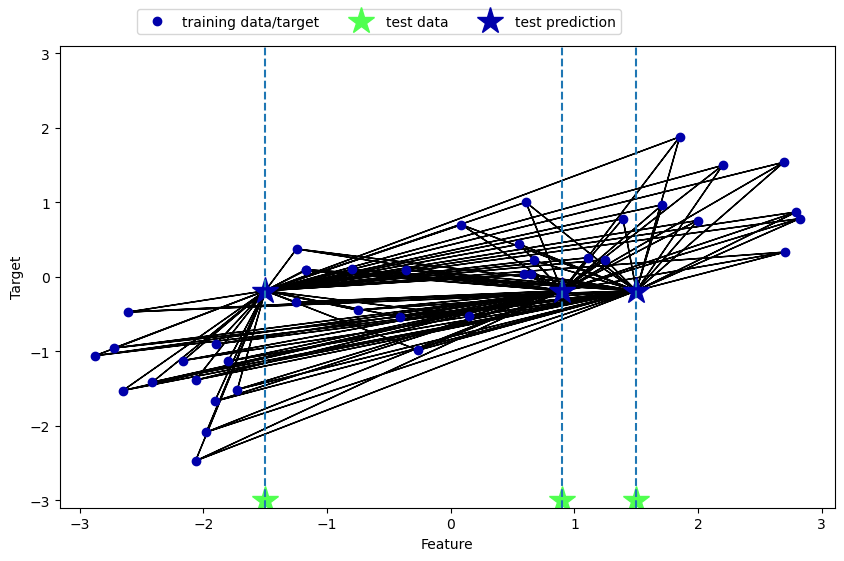

In [12]:
mglearn.plots.plot_knn_regression(n_neighbors=40)

In [13]:
from sklearn.neighbors import KNeighborsRegressor

X, y = mglearn.datasets.make_wave(n_samples=40)

# splits the wave daraset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# instantiate the model and set the number of neighbors to consider to 3
reg = KNeighborsRegressor(n_neighbors=3)
# fit the model using the training data and traiing targets 
reg.fit(X_train, y_train)

print('Test set predictions: \n{}'.format(reg.predict(X_test)))
print('Test set R^2: {:.2f}'.format(reg.score(X_test, y_test)))

Test set predictions: 
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]
Test set R^2: 0.83


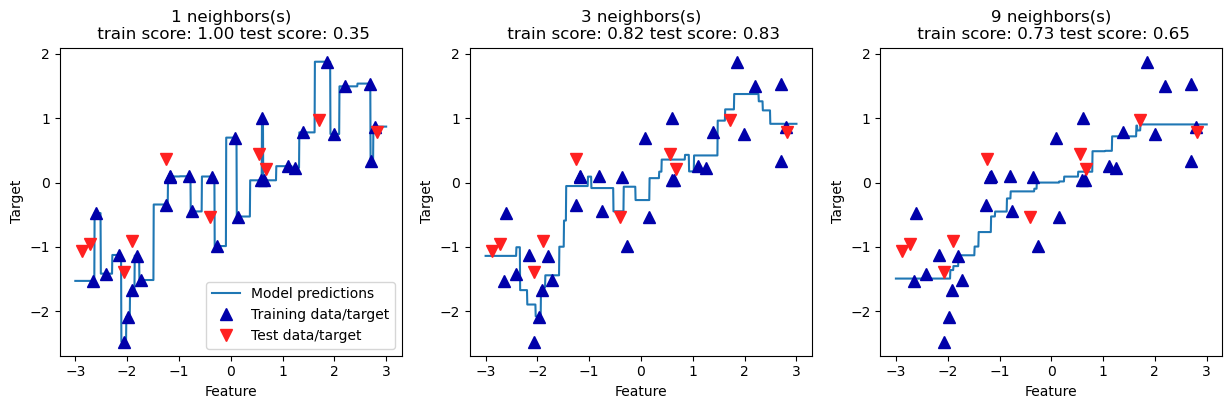

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
# create 1,000 data points, evenly spaaced between -3 and 3
line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
    # make predictions using 1, 3, or 9 neighbors
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)
    
    ax.set_title(
        '{} neighbors(s)\n train score: {:.2f} test score: {:.2f}'.format(
            n_neighbors, reg.score(X_train, y_train),
            reg.score(X_test, y_test)))
    ax.set_xlabel('Feature')
    ax.set_ylabel('Target')

axes[0].legend(['Model predictions', 'Training data/target',
               'Test data/target'], loc='best')

w[0]: 0.393906  b: -0.031804


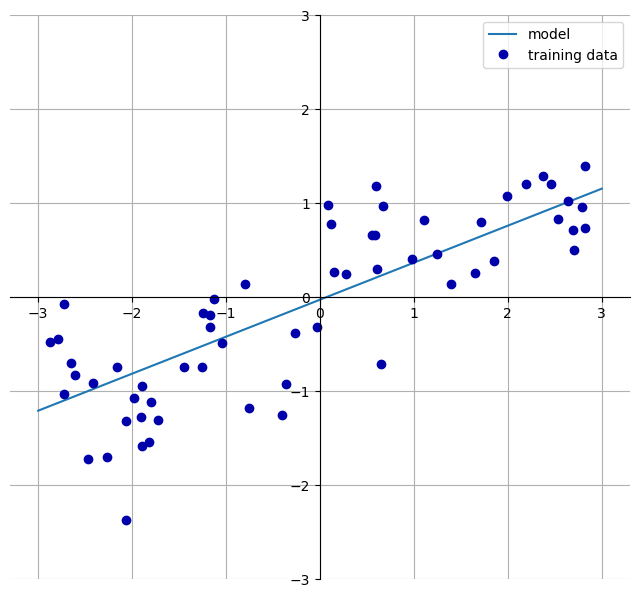

In [15]:
mglearn.plots.plot_linear_regression_wave()

In [16]:
from sklearn.linear_model import LinearRegression
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)

print('lr.coef_: {}'.format(lr.coef_))
print('lr.intercept_: {}'.format(lr.intercept_))


lr.coef_: [0.39390555]
lr.intercept_: -0.03180434302675973


In [17]:
print('Training set score: {:.2f}'.format(lr.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lr.score(X_test, y_test)))

Training set score: 0.67
Test set score: 0.66


In [18]:
X,  y = mglearn.datasets.load_extended_boston()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

print('Training set score: {:.2f}'.format(lr.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lr.score(X_test, y_test)))

Training set score: 0.95
Test set score: 0.61


In [19]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge.score(X_test, y_test)))

Training set score: 0.89
Test set score: 0.75


In [20]:
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge10.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge10.score(X_test, y_test)))


Training set score: 0.79
Test set score: 0.64


In [21]:
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print('Training set score: {:.2f}'.format(ridge01.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(ridge01.score(X_test, y_test)))

Training set score: 0.93
Test set score: 0.77


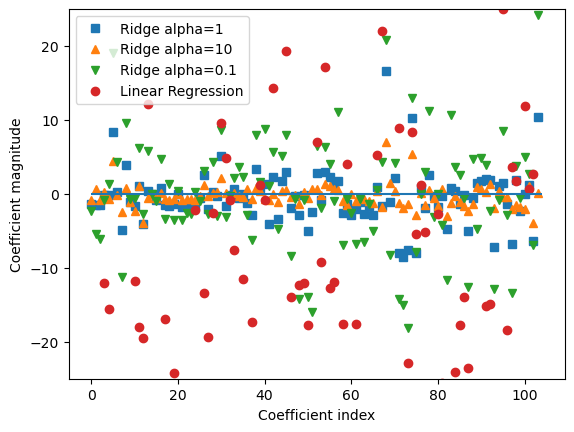

In [22]:
plt.plot(ridge.coef_, 's', label='Ridge alpha=1')
plt.plot(ridge10.coef_, '^', label='Ridge alpha=10')
plt.plot(ridge01.coef_, 'v', label='Ridge alpha=0.1')

plt.plot(lr.coef_, 'o', label='Linear Regression')
plt.xlabel('Coefficient index')
plt.ylabel('Coefficient magnitude')
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25,25)
plt.legend()

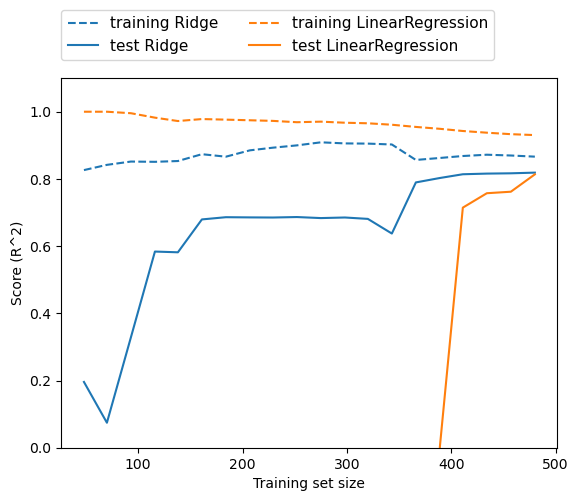

In [23]:
mglearn.plots.plot_ridge_n_samples()

In [24]:
from sklearn.linear_model import Lasso
x,  y = mglearn.datasets.load_extended_boston()

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
lasso = Lasso().fit(x_train, y_train)
print('Training set score: {:.2f}'.format(lasso.score(x_train, y_train)))
print('Test set score: {:.2f}'.format(lasso.score(x_test, y_test)))
print('Number of features used: {}'. format(np.sum(lasso.coef_ !=0)))

Training set score: 0.29
Test set score: 0.21
Number of features used: 4


In [25]:
# we increase the default setting of 'max iter'
# otherwise the model would warn us that we shopuld increase max_iter
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(x_train, y_train)
print('Training set score: {:.2f}'.format(lasso001.score(x_train, y_train)))
print('Test set score: {:.2f}'.format(lasso001.score(x_test, y_test)))
print('Number of feature used: {}'.format(np.sum(lasso001.coef_ !=0)))

Training set score: 0.90
Test set score: 0.77
Number of feature used: 33


In [26]:
lasso00001 = Lasso(alpha=0.0001, max_iter=100000).fit(x_train, y_train)
print('Training set score: {:.2f}'.format(lasso00001.score(x_train, y_train)))
print('Test set score: {}'.format(lasso00001.score(x_test, y_train)))
print('Number of feature used: {}'.format(np.sum(lasso00001.coef_ !=0)))

Training set score: 0.95


ValueError: Found input variables with inconsistent numbers of samples: [379, 127]

C:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


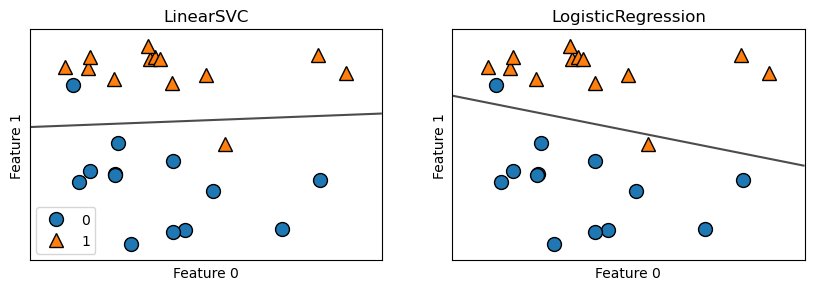

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

x, y = mglearn.datasets.make_forge()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for model, ax in zip([LinearSVC(), LogisticRegression()], axes):
    clf = model.fit(x, y)
    mglearn.plots.plot_2d_separator(clf, x, fill=False, eps=0.5,
                                   ax=ax, alpha=0.7)
    mglearn.discrete_scatter(x[:, 0], x[:, 1], y, ax=ax)
    ax.set_title('{}'.format(clf.__class__.__name__))
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')
axes[0].legend()

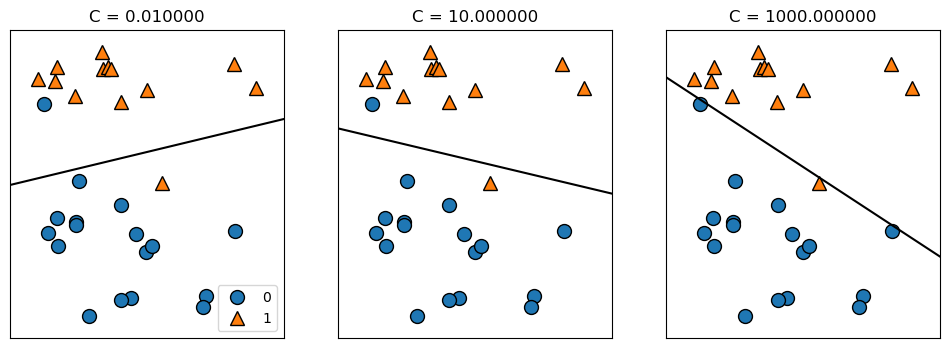

In [28]:
mglearn.plots.plot_linear_svc_regularization()

In [29]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)
logreg = LogisticRegression().fit(x_train, y_train)
print('Training set score: {:.3f}'.format(logreg.score(x_train, y_train)))
print('Test set score: {:.3f}'.format(logreg.score(x_test, y_test)))

Training set score: 0.946
Test set score: 0.958


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
logreg100 = LogisticRegression(C=100).fit(x_train, y_train)
print('Training set score: {:.3f}'.format(logreg100.score(x_train, y_train)))
print('Test set score: {:.3f}'.format(logreg100.score(x_test, y_test)))

Training set score: 0.946
Test set score: 0.958


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
logreg001 = LogisticRegression(C=0.01).fit(x_train, y_train)
print('Training set score: {:.3f}'.format(logreg001.score(x_train, y_train)))
print('Test set score:{:.3f}'.format(logreg001.score(x_test, y_test)))

C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training set score: 0.934
Test set score:0.930


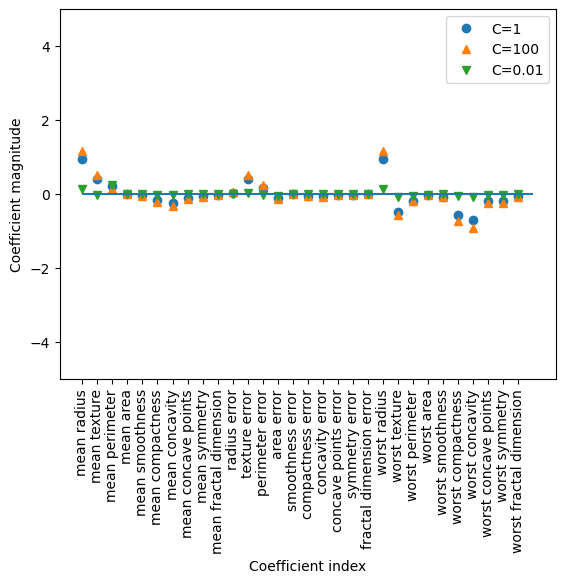

In [32]:
plt.plot(logreg.coef_.T, 'o', label='C=1')
plt.plot(logreg100.coef_.T, '^', label='C=100')
plt.plot(logreg001.coef_.T, 'v', label='C=0.01')
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.ylim(-5, 5)
plt.xlabel('Coefficient index')
plt.ylabel('Coefficient magnitude')
plt.legend()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Training accuracy of L1 logreg with C=0.001: 0.95
Test accuracy of l1 logreg with C=0.001
Training accuracy of L1 logreg with C=1.000: 0.95
Test accuracy of l1 logreg with C=1.000
Training accuracy of L1 logreg with C=100.000: 0.95
Test accuracy of l1 logreg with C=100.000


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


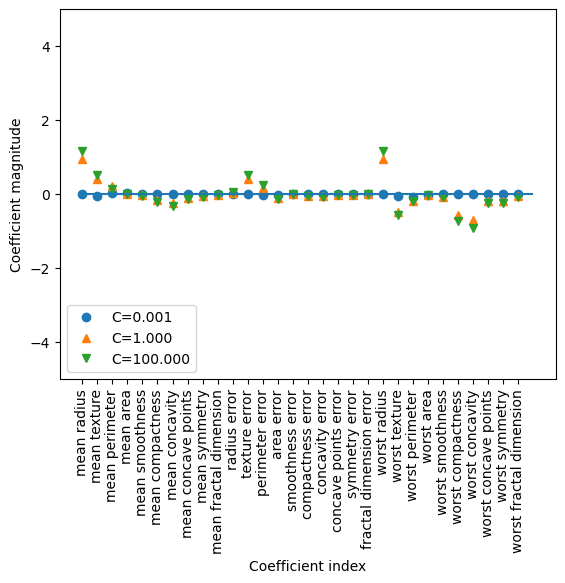

In [33]:
for C, marker in zip([0.001, 1, 100], ['o', '^', 'v']):
    lr_l1 = LogisticRegression(C=C, penalty='l2').fit(x_train, y_train)
    print('Training accuracy of L1 logreg with C={:.3f}: {:.2f}'.format(
        C, lr_l1.score(x_train, y_train)))
    print('Test accuracy of l1 logreg with C={:.3f}'.format(
        C, lr_l1.score(x_test, y_test)))
    plt.plot(lr_l1.coef_.T, marker, label='C={:.3f}'.format(C))
    
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.xlabel('Coefficient index')
plt.ylabel('Coefficient magnitude')

plt.ylim(-5, 5)
plt.legend(loc=3)

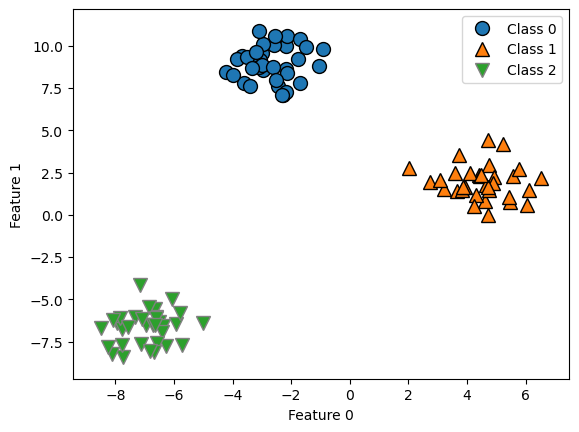

In [34]:
from sklearn.datasets import make_blobs

x, y = make_blobs(random_state=42)
mglearn.discrete_scatter(x[:, 0], x[:,1], y)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend(['Class 0', 'Class 1', 'Class 2'])

In [35]:
linear_svm = LinearSVC().fit(x, y)
print('Coefficient shape: ', linear_svm.coef_.shape)
print('Intercept shape: ', linear_svm.intercept_.shape)

Coefficient shape:  (3, 2)
Intercept shape:  (3,)


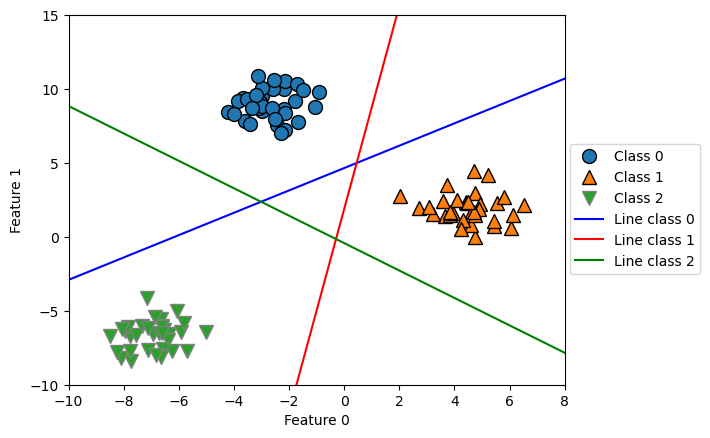

In [36]:
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_,
                                 ['b', 'r', 'g']):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.ylim(-10, 15)
plt.xlim(-10, 8)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1',
           'Line class 2'], loc=(1.01, 0.3))

Text(0, 0.5, 'Feature 1')

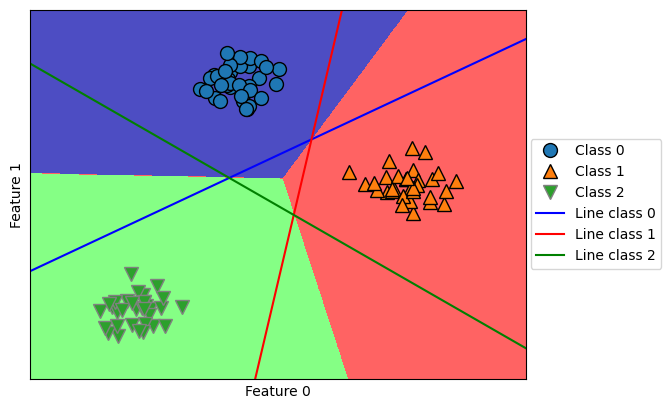

In [37]:
mglearn.plots.plot_2d_classification(linear_svm, x, fill=True, alpha=0.7)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
line = np.linspace(-15, 15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_,
                                 ['b', 'r', 'g']):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1',
           'Line class 2'], loc=(1.01, 0.3))
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

In [38]:
x = np.array([[0, 1, 0, 1],
              [1, 0, 1, 1],
              [0, 0, 0, 1], 
              [1, 0, 1, 0]])

y = np.array([0, 1, 0, 1])

counts = {}
for label in np.unique(y):
    # iterare over each class
    # count(sum) enteries of 1 per feature
    counts[label] = x[y==label].sum(axis=0)
print('Feature counts:\n{}'.format(counts))    

Feature counts:
{0: array([0, 1, 0, 2]), 1: array([2, 0, 2, 1])}


In [39]:
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
x_train, x_test, y_train, y_test =train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(x_train, y_train)
print('Accuracy on training set: {:.3f}'.format(tree.score(x_train, y_train)))
print('Accuracy on test setL {:.3f}'.format(tree.score(x_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test setL 0.937


In [40]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(x_train, y_train)

print('Accuracy on training set: {:.3f}'.format(tree.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(tree.score(x_test, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.951


In [41]:
print('Feature importance:\n{}'.format(tree.feature_importances_))

Feature importance:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


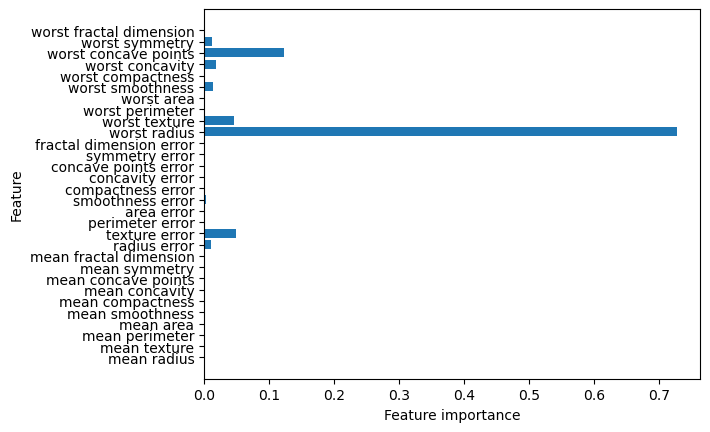

In [42]:
def plot_feature_importance_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel('Feature')
plot_feature_importance_cancer(tree)

Feature importances: [0. 1.]


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

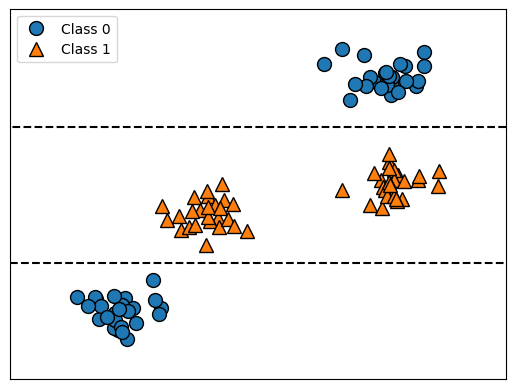

In [43]:
tree = mglearn.plots.plot_tree_not_monotone()
display(tree)

Text(0, 0.5, 'Price in $/Mbyte')

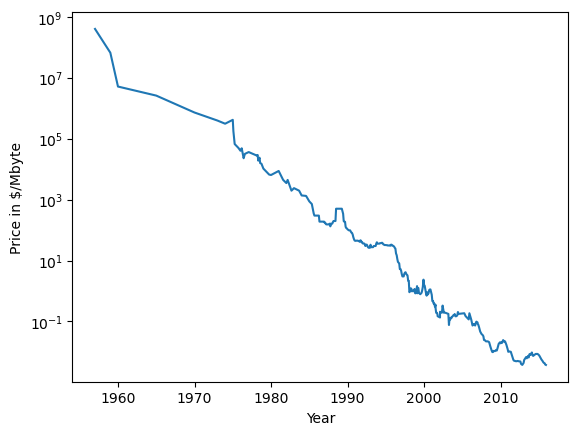

In [44]:
import pandas as pd
ram_prices = pd.read_csv('ram_price.csv')

plt.semilogy(ram_prices.date, ram_prices.price)
plt.xlabel('Year')
plt.ylabel('Price in $/Mbyte')

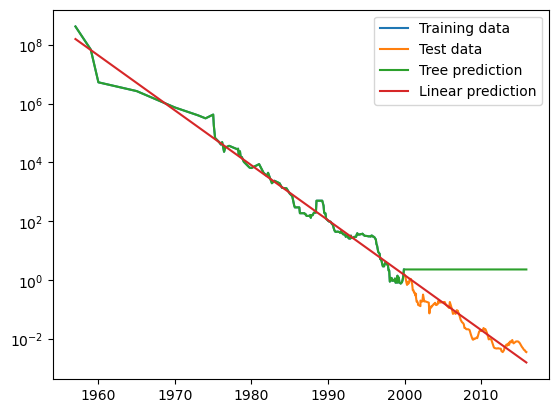

In [45]:
from sklearn.tree import DecisionTreeRegressor
# use historical data to forecast prices after the year 2000
data_train = ram_prices[ram_prices.date < 2000]
data_test = ram_prices[ram_prices.date >= 2000]

# predit pricesbased on date
x_train = np.array(data_train.date)[:, np.newaxis]
# we use a log-transform to get a simpler relationship of data to targert
y_train = np.log(data_train.price)

tree = DecisionTreeRegressor().fit(x_train, y_train)
linear_reg = LinearRegression().fit(x_train, y_train)

# predict on all data
x_all = np.array(ram_prices.date)[:, np.newaxis]

pred_tree = tree.predict(x_all)
pred_lr = linear_reg.predict(x_all)

# undo log-transform
price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

plt.semilogy(data_train.date, data_train.price, label='Training data')
plt.semilogy(data_test.date, data_test.price, label='Test data')
plt.semilogy(ram_prices.date, price_tree, label='Tree prediction')
plt.semilogy(ram_prices.date, price_lr, label='Linear prediction')
plt.legend()

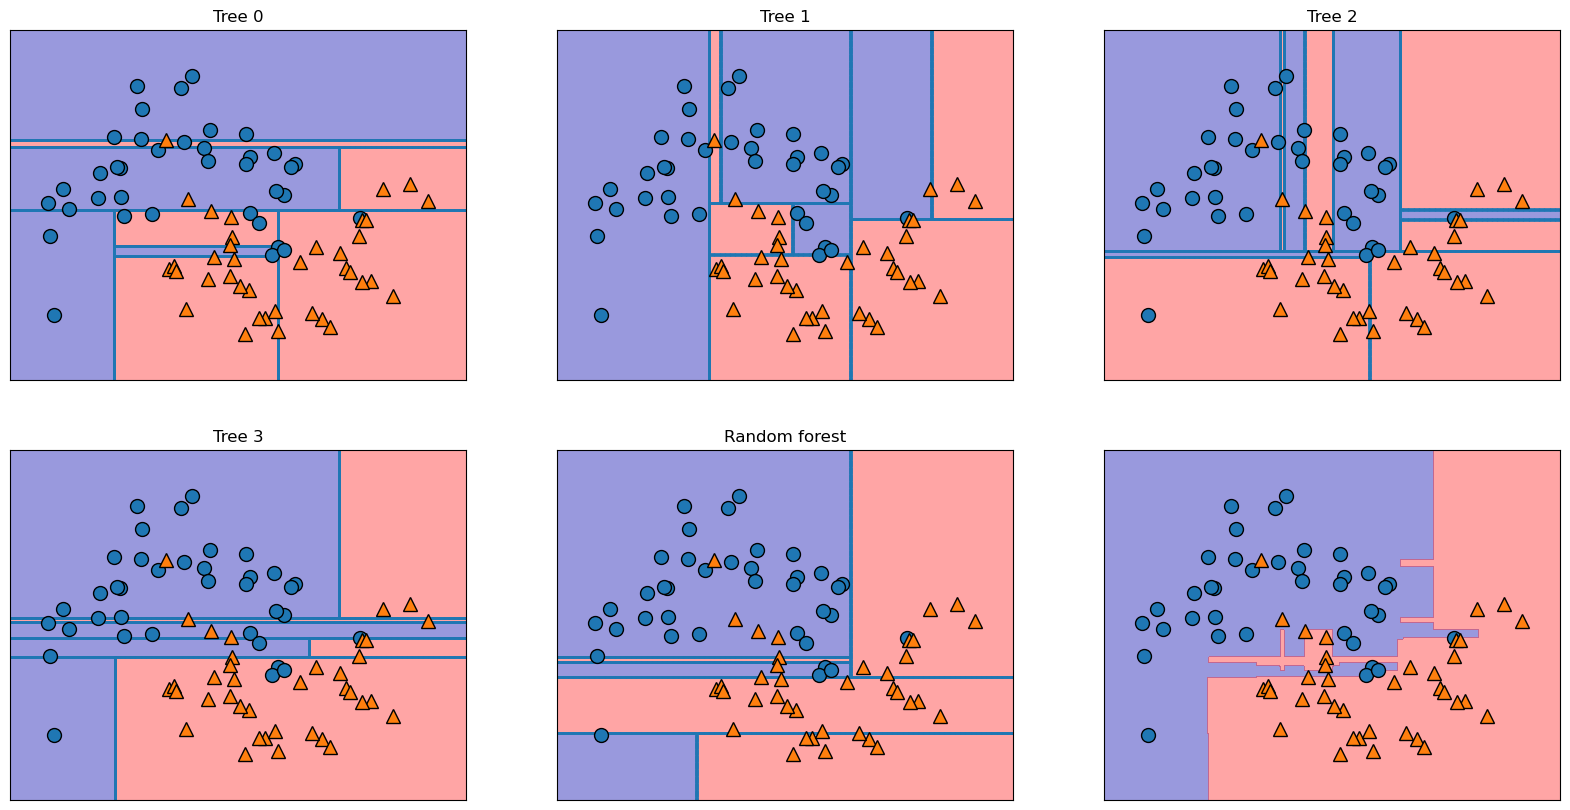

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons

x, y = make_moons(n_samples=100, noise=0.25, random_state=3)
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,
                                                    random_state=42)
forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(x_train, y_train)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title('Tree {}'.format(i))
    mglearn.plots.plot_tree_partition(x_train, y_train, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(forest, x_train, fill=True, ax=axes[-1, -1],
                                alpha=0.4)
axes[-1, 1].set_title('Random forest')
mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train)     

In [47]:
x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(x_train, y_train)

print('Accuracy on treining set: {:.3f}'.format(forest.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(forest.score(x_test, y_test)))

Accuracy on treining set: 1.000
Accuracy on test set: 0.972


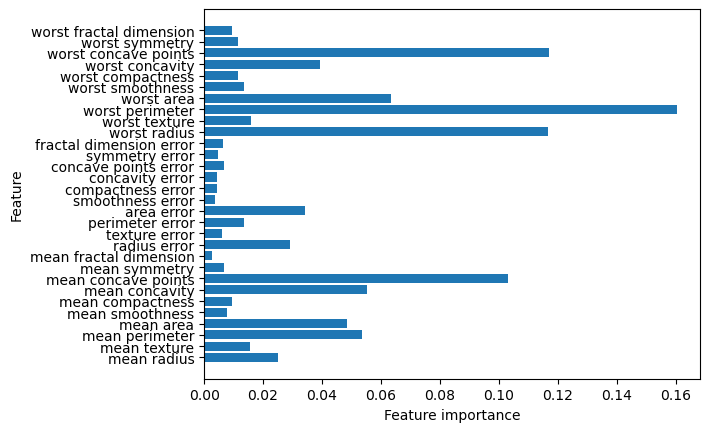

In [48]:
plot_feature_importance_cancer(forest)

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(x_train, y_train)

print('Accuracy on training set: {:.3f}'.format(gbrt.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(gbrt.score(x_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.965


In [50]:
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(x_train, y_train)

print('Acci=uracy on training set: {:.3f}'.format(gbrt.score(x_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(gbrt.score(x_test, y_test)))

Acci=uracy on training set: 0.991
Accuracy on test set: 0.972


In [51]:
gbrt = GradientBoostingClassifier(random_state=0, learning_rate=0.01)
gbrt.fit(x_train, y_train)

print('Accuracy on training set: {:.3f}'.format(gbrt.score(x_train, y_train)))
print('accuracy on test set: {:.3f}'.format(gbrt.score(x_test, y_test)))

Accuracy on training set: 0.988
accuracy on test set: 0.965


## Kernelized Support vector Machines

### Linear models and nonlinear features

Text(0, 0.5, 'Feature 1')

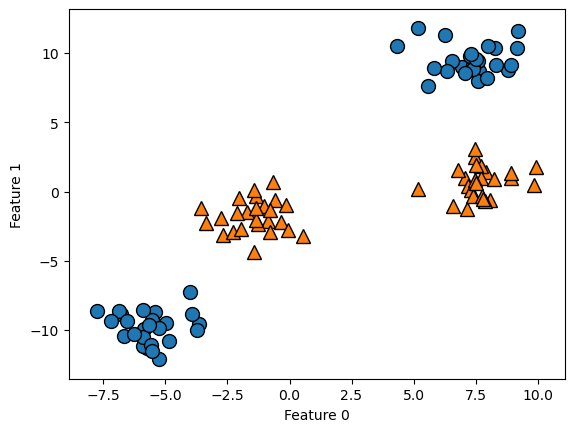

In [104]:
x, y = make_blobs(centers=4, random_state=8)
y = y % 2

mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

Text(0, 0.5, 'Feature 1')

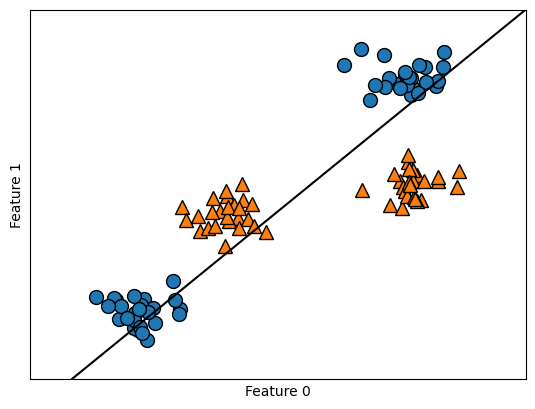

In [55]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC(max_iter=10000).fit(x, y)

mglearn.plots.plot_2d_separator(linear_svm, x)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

Text(0.5, 0, 'Feature1 ** 2')

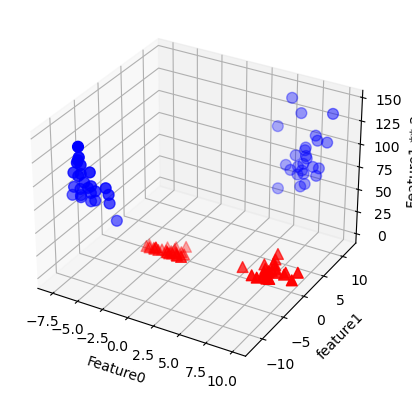

In [103]:
# add the squared first feature
%matplotlib inline
x_new = np.hstack([x, x[:, 1:]**2])

from mpl_toolkits.mplot3d import Axes3D, axes3d
figure = plt.figure()

# visualize in 3D
# ax = Axes3D(figure, elev=-152, azim=-26)
ax = plt.axes(projection='3d')

# plot first all the points with y ==0, then all with y == 1
mask = y == 0
ax.scatter(x_new[mask, 0], x_new[mask, 1], x_new[mask, 2], c='b', s=60)
ax.scatter(x_new[~mask, 0], x_new[~mask, 1], x_new[~mask, 2], c='r', marker='^', s=60)

ax.set_xlabel('Feature0')
ax.set_ylabel('feature1')
ax.set_zlabel('Feature1 ** 2')

C:\Users\Rio Agustian\AppData\Local\Temp\ipykernel_26012\1073102057.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x_new[mask, 0], x_new[mask, 1], x_new[mask, 2], c='b',
C:\Users\Rio Agustian\AppData\Local\Temp\ipykernel_26012\1073102057.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x_new[~mask, 0], x_new[~mask, 1], x_new[~mask, 2], c='r', marker='^',


Text(0.5, 0, 'Feature0 ** 2')

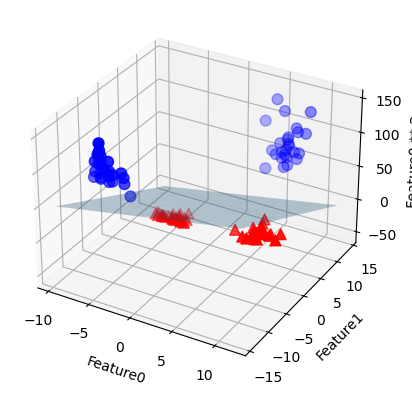

In [114]:
linear_svm_3d = LinearSVC(max_iter=100000).fit(x_new, y) 
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_
%matplotlib inline
# show linear decision boundary
figure = plt.figure
ax = plt.axes(projection='3d')
xx = np.linspace(x_new[:, 0].min() - 2, x_new[:, 0].max() + 2, 50)
yy = np.linspace(x_new[:, 1].min() - 2, x_new[:, 1].max() + 2, 50)

XX, YY = np.meshgrid(xx, yy)
ZZ = (coef[0] * XX + coef[1] * YY + intercept) / -coef[2]
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=.3)
ax.scatter(x_new[mask, 0], x_new[mask, 1], x_new[mask, 2], c='b',
          cmap=mglearn.cm2, s=60)
ax.scatter(x_new[~mask, 0], x_new[~mask, 1], x_new[~mask, 2], c='r', marker='^',
          cmap=mglearn.cm2, s=60)

ax.set_xlabel('Feature0')
ax.set_ylabel('Feature1')
ax.set_zlabel('Feature0 ** 2')

Text(0, 0.5, 'Feature 1')

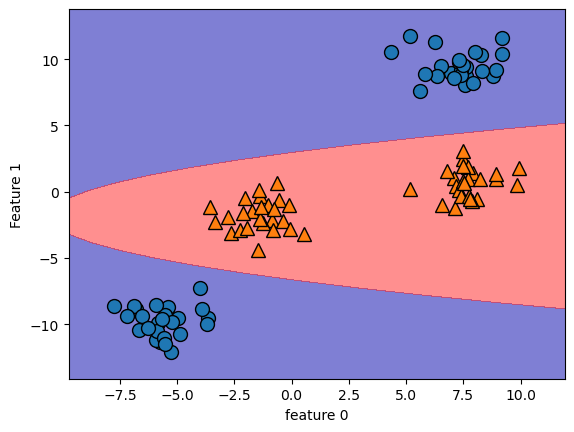

In [125]:
ZZ = YY ** 2
dec = linear_svm_3d.decision_function(np.c_[XX.ravel(), YY.ravel(), ZZ.ravel()])
plt.contourf(XX, YY, dec.reshape(XX.shape), levels=[dec.min(), 0, dec.max()],
           cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)
plt.xlabel('feature 0')
plt.ylabel('Feature 1')

### The kernel trick

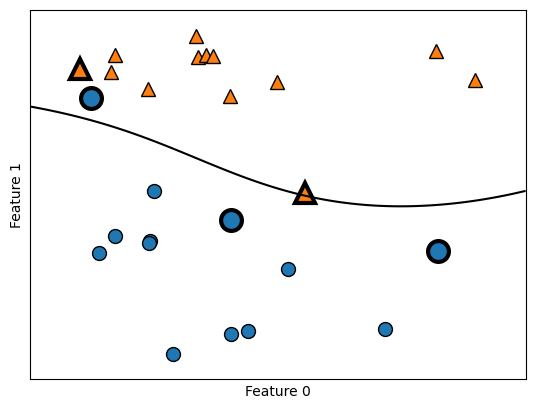

In [6]:
from sklearn.svm import SVC
%matplotlib inline

x, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(x, y)
mglearn.plots.plot_2d_separator(svm, x, eps=0.5)
mglearn.discrete_scatter(x[:, 0], x[:, 1], y)

# plot support vectors
sv = svm.support_vectors_

# class labels of support vectors are given by the sig of the dual coefficients
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.show()

### Tunning SVM parameters

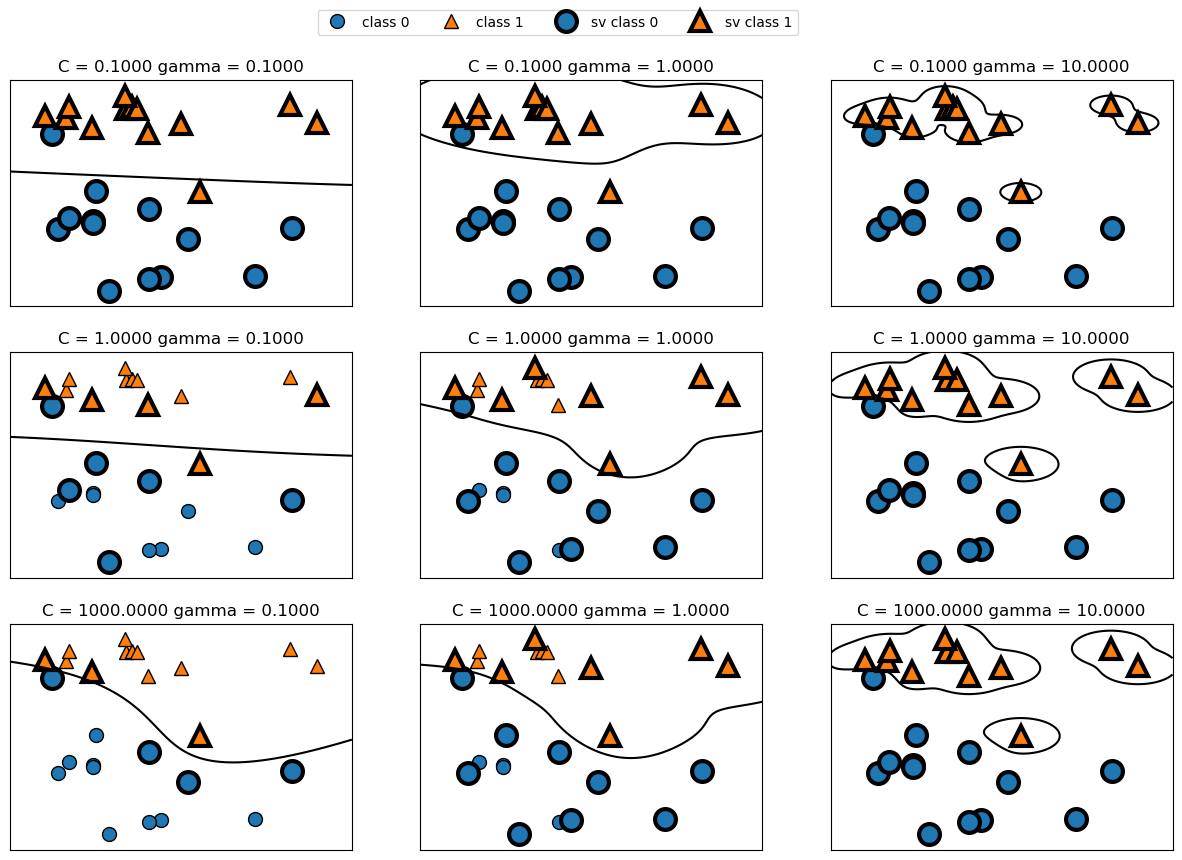

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)

axes[0, 0].legend(['class 0', 'class 1', 'sv class 0', 'sv class 1'],
                 ncol=4, loc=(.9, 1.2))


In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

x_train, x_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

svc = SVC()
svc.fit(x_train, y_train)

print('Accuracy on training set: {:.2f}'.format(svc.score(x_train, y_train)))
print('Accuracy on test set: {:.2f}'.format(svc.score(x_test, y_test)))

Accuracy on training set: 0.90
Accuracy on test set: 0.94


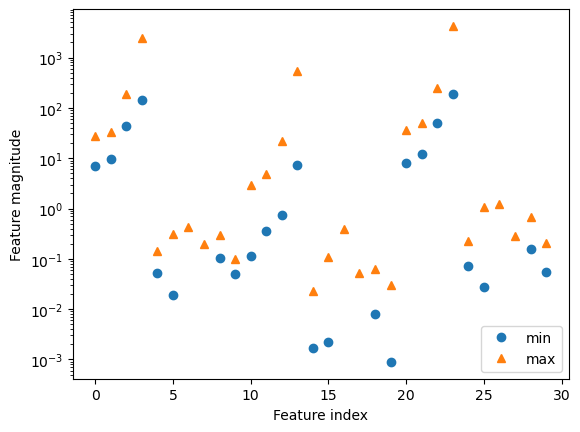

In [23]:
plt.plot(x_train.min(axis=0), 'o', label='min')
plt.plot(x_train.max(axis=0), '^', label='max')
plt.legend(loc=4)
plt.xlabel('Feature index')
plt.ylabel('Feature magnitude')
plt.yscale('log')

### Preprosessing data for SVMs

In [25]:
# compute the minimum value per feature on the training set
min_on_training = x_train.min(axis=0)

#compute the range of each feature (max - min) on the training set
range_on_training = (x_train - min_on_training).max(axis=0)

# substract the min, and divided by range
# afterward, min=0 and max=1 for each feature
x_train_scaled = (x_train - min_on_training) / range_on_training

print('Minimum for each feature\n{}'.format(x_train_scaled.min(axis=0)))
print('Maximum for each feature\n{}'.format(x_train_scaled.max(axis=0)))

Minimum for each feature
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Maximum for each feature
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [28]:
# use THE SAME transformation on the test set
# using min and range of the training sert (see Chapter 3 for details)
x_test_scaled = (x_test - min_on_training) / range_on_training

svc = SVC()
svc.fit(x_train_scaled, y_train)

print('Accuracy on training set: {:.3f}'.format(
    svc.score(x_train_scaled, y_train)))
print('Accuracy on test set: {:.3f}'.format(svc.score(x_test_scaled, y_test)))

Accuracy on training set: 0.984
Accuracy on test set: 0.972


In [31]:
svc = SVC(C=1000)
svc.fit(x_train_scaled, y_train)

print('Accuracy on training set: {:.3f}'.format(svc.score(x_train_scaled, y_train)))
print('Accuracy on test set: {:.3f}'.format(svc.score(x_test_scaled, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.958
